In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error,r2_score

In [ ]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

In [ ]:
# Select one feature (Average Rooms) and Target (Median House Value)
X = df[['AveRooms']].values
y = df['MedHouseVal'].values.reshape(-1,1)

In [ ]:
# Add Bias Term
X_b = np.c_[np.ones((len(X),1)), X]

In [ ]:
theta_normal = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

y_pred_normal = X_b @ theta_normal

print("----- Normal Equation -----")
print("Intercept :", theta_normal[0][0])
print("Slope     :", theta_normal[1][0])
print("MSE        :", mean_squared_error(y,y_pred_normal))
print("R2 Score   :", r2_score(y,y_pred_normal))


----- Normal Equation -----
Intercept : 1.6838115086404832
Slope     : 0.0708687932804052
MSE        : 1.3008070902505424
R2 Score   : 0.023088282755354017


In [ ]:
def compute_cost(X, y, theta):
    m = len(y)
    predictions = X @ theta
    cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return cost


def gradient_descent(X, y, theta, learning_rate, iterations):

    m = len(y)
    cost_history = []

    for i in range(iterations):

        gradients = (1 / m) * X.T @ (X @ theta - y)

        theta = theta - learning_rate * gradients

        cost_history.append(compute_cost(X, y, theta))

    return theta, cost_history


theta = np.zeros((2,1))

learning_rate = 0.001
iterations = 1000

theta_gd, cost_history = gradient_descent(
    X_b,
    y,
    theta,
    learning_rate,
    iterations
)

y_pred_gd = X_b @ theta_gd

print("\n----- Gradient Descent -----")
print("Intercept :", theta_gd[0][0])
print("Slope     :", theta_gd[1][0])
print("MSE       :", mean_squared_error(y, y_pred_gd))
print("R2 Score  :", r2_score(y, y_pred_gd))


----- Gradient Descent -----
Intercept : 0.30209997653075465
Slope     : 0.2826073529823789
MSE       : 1.6291507228490774
R2 Score  : -0.22349919695034104


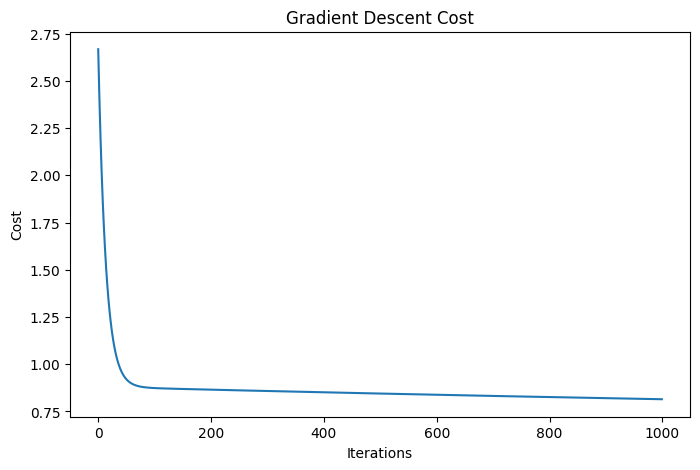

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Gradient Descent Cost")
plt.show()